# LSTM Movie Review Sentiment Analyzer

**Assignment:** Predict the sentiment (Positive / Negative) of movie reviews using an LSTM (Long Short-Term Memory) recurrent neural network.

**Dataset:** IMDB Dataset of 50K Movie Reviews (Kaggle, NLP section)
- Kaggle page: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
- Dataset slug: `lakshmi25npathi/imdb-dataset-of-50k-movie-reviews`
- File inside the dataset: `IMDB Dataset.csv`
- Columns: `review` (raw review text), `sentiment` (`positive` / `negative`)
- 50,000 rows, perfectly balanced (25,000 positive / 25,000 negative)

**Dataset path (see "0. Get the Dataset" below for how each path is produced):**
- On Kaggle Notebooks (after adding the dataset): `/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv`
- Local machine (via Kaggle API download): `./data/IMDB Dataset.csv`
- Local machine (via `kagglehub`): printed at runtime, typically `~/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1/IMDB Dataset.csv`

---

## Assignment Outline
1. Get the dataset
2. Load & explore the data
3. Text cleaning / preprocessing
4. Train-test split
5. Tokenization & padding (sequence encoding)
6. Build the LSTM model
7. Compile & train the model
8. Evaluate on the test set (accuracy, confusion matrix, classification report)
9. Plot training curves (accuracy/loss vs. epochs)
10. Predict sentiment on a custom review
11. Conclusion / discussion questions


In [1]:
import os

# --- EDIT THIS: pick the path that matches how you obtained the dataset (see Section 0) ---
CANDIDATE_PATHS = [
    "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv",  # Option A: Kaggle Notebooks
   
]

DATA_PATH = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), CANDIDATE_PATHS[0])

# If you used kagglehub (Option C), uncomment and use this instead:
# import kagglehub
# kh_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
# DATA_PATH = os.path.join(kh_path, "IMDB Dataset.csv")

print("Using dataset path:", DATA_PATH)


Using dataset path: /kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


## 2. Imports

In [2]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 3. Load & Explore the Data

In [3]:
import os

base = "/kaggle/input"
found_path = None

for root_dir in os.listdir(base):
    candidate_dir = os.path.join(base, root_dir)
    for f in os.listdir(candidate_dir):
        if f.endswith(".csv") and "imdb" in (f.lower() + root_dir.lower()):
            found_path = os.path.join(candidate_dir, f)

print("Available input folders:", os.listdir(base))
print("Auto-detected path:", found_path)

DATA_PATH = found_path if found_path else "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"

Available input folders: ['datasets']
Auto-detected path: None


In [4]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


sentiment
positive    25000
negative    25000
Name: count, dtype: int64


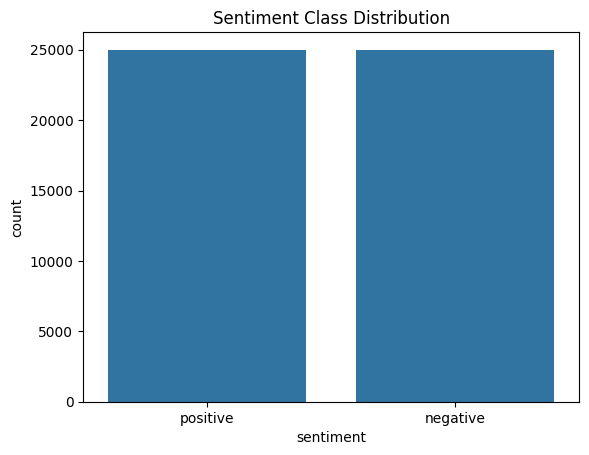

In [5]:
# Class balance
print(df['sentiment'].value_counts())
sns.countplot(data=df, x='sentiment')
plt.title("Sentiment Class Distribution")
plt.show()


count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_len, dtype: float64


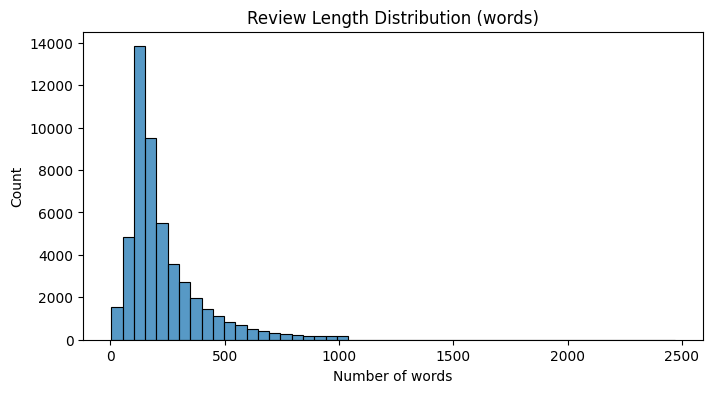

In [6]:
# Review length distribution (in words) — helps choose MAX_LEN later
df['review_len'] = df['review'].apply(lambda x: len(x.split()))
print(df['review_len'].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df['review_len'], bins=50)
plt.title("Review Length Distribution (words)")
plt.xlabel("Number of words")
plt.show()


## 4. Text Cleaning / Preprocessing

Raw IMDB reviews contain HTML tags (`<br />`), punctuation, and mixed case. We clean each review before tokenizing.


In [7]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r"[^a-z\s']", ' ', text)   # keep apostrophes so "isn't"/"didn't" stay intact
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [8]:
# Encode target: negative -> 0, positive -> 1
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})
df[['sentiment', 'label']].drop_duplicates()


,sentiment,label
0,positive,1
3,negative,0


## 5. Train-Test Split

In [9]:
df.columns

Index(['review', 'sentiment', 'review_len', 'label'], dtype='object')

In [10]:
df['clean_review'] = df['review'].apply(clean_text)
df[['review', 'clean_review']].head(3)

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...


In [11]:
X = df['clean_review'].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))


Train size: 40000
Test size : 10000


## 6. Tokenization & Padding

We convert text into integer sequences (word -> index) and pad them to a fixed length so they can be fed into the LSTM.


In [12]:
VOCAB_SIZE = 20000   # keep the top 20k most frequent words
MAX_LEN = 200         # pad/truncate every review to 200 tokens
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)
print("Vocabulary size found:", len(tokenizer.word_index))


X_train_pad shape: (40000, 200)
X_test_pad shape : (10000, 200)
Vocabulary size found: 107720


## 7. Build the LSTM Model

Architecture: `Embedding -> SpatialDropout1D -> Bidirectional LSTM -> Dense (sigmoid)`


In [13]:
EMBEDDING_DIM = 128

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=False)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1784534485.608220      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 8. Train the Model

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 481s 837ms/step - accuracy: 0.7244 - loss: 0.5505 - val_accuracy: 0.8092 - val_loss: 0.4392
Epoch 2/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 471s 836ms/step - accuracy: 0.8229 - loss: 0.4177 - val_accuracy: 0.8470 - val_loss: 0.3572
Epoch 3/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 469s 833ms/step - accuracy: 0.8693 - loss: 0.3284 - val_accuracy: 0.8512 - val_loss: 0.3623
Epoch 4/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 471s 836ms/step - accuracy: 0.8886 - loss: 0.2869 - val_accuracy: 0.8618 - val_loss: 0.3540
Epoch 5/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 471s 837ms/step - accuracy: 0.9026 - loss: 0.2543 - val_accuracy: 0.8597 - val_loss: 0.3775
Epoch 6/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 469s 833ms/step - accuracy: 0.9249 - loss: 0.2060 - val_accuracy: 0.8640 - val_loss: 0.3847
Epoch 7/15
563/563 ━━━━━━━━━━━━━━━━━━━━ 466s 828ms/step - accuracy: 0.9387 - loss: 0.1706 - val_accuracy: 0.8572 - val_loss: 0.4154


## 9. Evaluate on the Test Set

In [15]:
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 0.3601
Test Accuracy: 0.8595


313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 146ms/step
              precision    recall  f1-score   support

    negative       0.85      0.88      0.86      5000
    positive       0.87      0.84      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



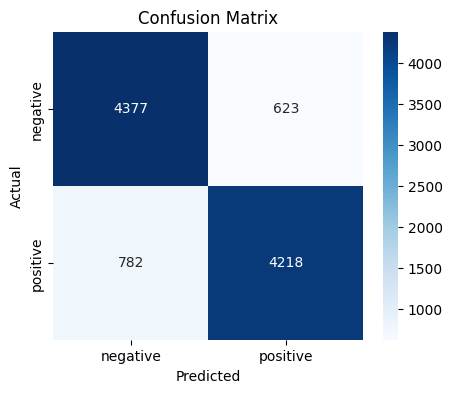

In [16]:
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 10 Training Curves (Accuracy & Loss vs. Epochs)

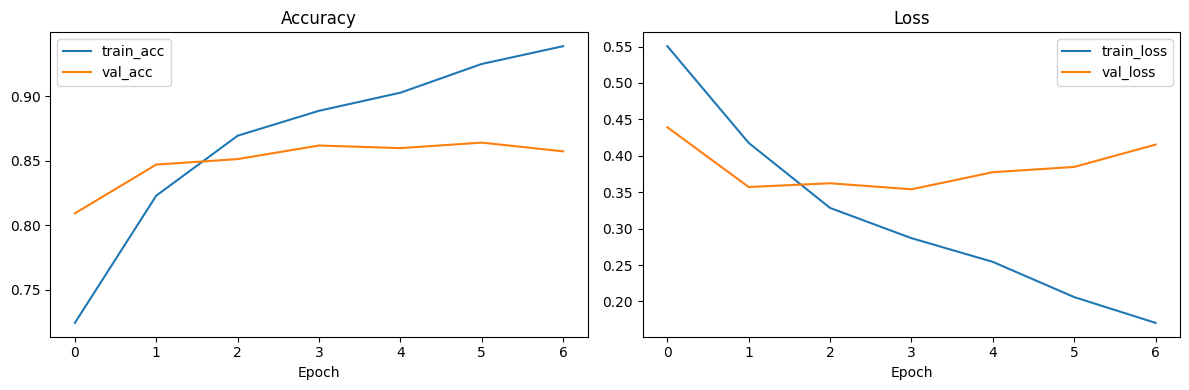

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train_acc')
axes[0].plot(history.history['val_accuracy'], label='val_acc')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train_loss')
axes[1].plot(history.history['val_loss'], label='val_loss')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Predict Sentiment on a Custom Review

In [18]:
def predict_sentiment(text: str) -> str:
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    label = 'positive' if prob > 0.5 else 'negative'
    return f"{label} (confidence: {prob:.2f})"

sample_reviews = [
    "This movie was an absolute masterpiece, the acting and story blew me away!",
    "Waste of time. Boring plot, terrible acting, I want my two hours back.",
    "It was okay, not the best but not the worst movie I've seen either."
]

for review in sample_reviews:
    print(f"Review: {review}\nPredicted sentiment: {predict_sentiment(review)}\n")


Review: This movie was an absolute masterpiece, the acting and story blew me away!
Predicted sentiment: positive (confidence: 0.92)

Review: Waste of time. Boring plot, terrible acting, I want my two hours back.
Predicted sentiment: negative (confidence: 0.00)

Review: It was okay, not the best but not the worst movie I've seen either.
Predicted sentiment: negative (confidence: 0.13)

